In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd 

Zadanie 1 — Pierwszy klasyfikator KNN
Wygeneruj dane z dwiema klasami i dwiema cechami.
Zbuduj model KNN (np. k=5).
Dopasuj i wykonaj predykcję.
Narysuj punkty i granicę decyzyjną.


In [3]:
X, y = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2, 
    n_classes=2, 
    n_redundant=0,
    random_state=42
)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()

In [6]:
#skalowanie cech niezbedne dla knn
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
knn.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [9]:
y_pred = knn.predict(X_test_scaled)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0])

In [10]:
y_test

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

In [11]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        19
           1       0.81      0.81      0.81        21

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



Narysuj punkty i granicę decyzyjną. - 


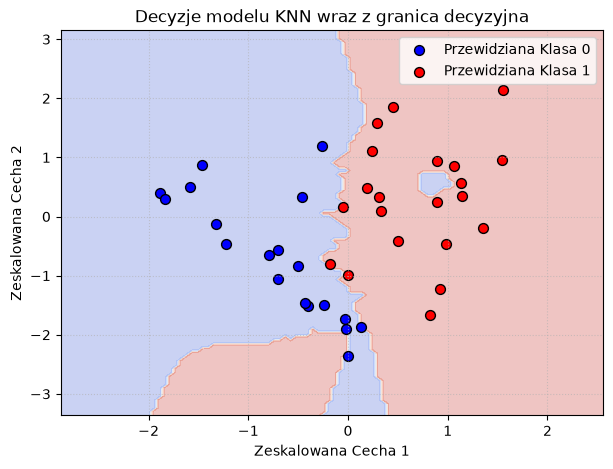

In [23]:
plt.figure(figsize=(7, 5))

DecisionBoundaryDisplay.from_estimator(
    knn, X_test_scaled, response_method="predict", 
    cmap=plt.cm.coolwarm, alpha=0.3, ax=plt.gca()
)

plt.scatter(X_test_scaled[y_pred == 0, 0], X_test_scaled[y_pred == 0, 1], color='blue', edgecolors='k', s=50, label='Przewidziana Klasa 0')
plt.scatter(X_test_scaled[y_pred == 1, 0], X_test_scaled[y_pred == 1, 1], color='red', edgecolors='k', s=50, label='Przewidziana Klasa 1')

plt.xlabel('Zeskalowana Cecha 1')
plt.ylabel('Zeskalowana Cecha 2')
plt.title('Decyzje modelu KNN wraz z granica decyzyjna')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

Funkcja DecisionBoundaryDisplay bierze Twój obszar wykresu (np. od -3 do 3 na obu osiach) i dzieli go na tysiące malutkich kwadracików (jak piksele na ekranie).

2. Dla każdego pojedynczego piksela (nawet tam, gdzie nie ma Twoich punktów) algorytm KNN wykonuje standardowe obliczenia:Mierzy odległość euklidesową od tego piksela do wszystkich Twoich prawdziwych punktów treningowych.Wybiera \(k\) najbliższych sąsiadów (np. 5).Sprawdza, która klasa dominuje wśród tych sąsiadów.

3.Jeśli dla danego piksela wygrała klasa 0, komputer koloruje ten jeden piksel na jasnoniebiesko. Jeśli klasa 1 – na jasnoczerwono.

Zadanie 2 — Wpływ liczby sąsiadów (k)
Podziel dane na treningowe/testowe.
Dopasuj KNN dla k = 1, 3, 5, 15, 30.
Policz accuracy dla każdego k.
Narysuj wykres accuracy vs k, wskaż optymalne k.


[0.85, 0.85, 0.8, 0.775, 0.8, 0.775]

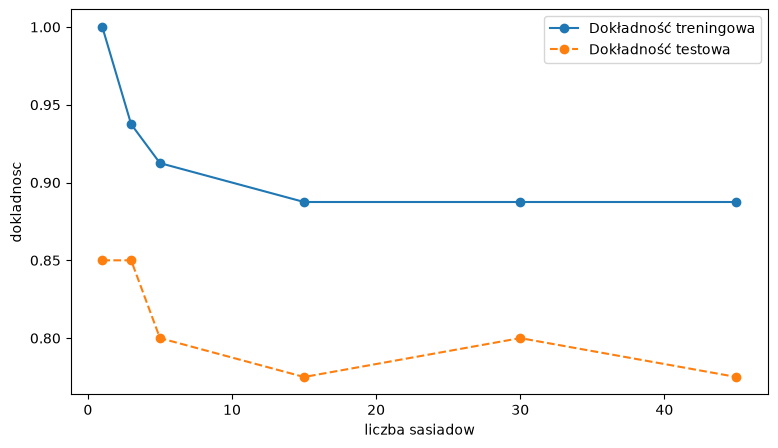

In [19]:
def diff_knn(X_train, X_test, y_train, y_test, neighbors_list):
    test_scores = []
    train_scores = []
    
    for k in neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    plt.figure(figsize=(9, 5))
    plt.plot(
        neighbors_list,
        train_scores,
        label="Dokładność treningowa",
        marker="o",
    )

    
    
    plt.plot(
        neighbors_list,
        test_scores,
        label="Dokładność testowa",
        marker="o",
        linestyle="--",
        
    )

    plt.xlabel("liczba sasiadow")
    plt.ylabel("dokladnosc")
    plt.legend()
    return test_scores        
    
diff_knn(X_train, X_test, y_train, y_test, [1, 3, 5, 15, 30,45])


k= 3 najbardziej optymalne

Zadanie 3 — Znaczenie skalowania cech
Wygeneruj cechy o różnych skalach (0-1 i 0-1000).
Dopasuj KNN bez skalowania.
Przeskaluj (standaryzacja) i dopasuj ponownie.
Porównaj wyniki.


In [123]:
np.random.seed(42)
cecha_mala = np.random.uniform(0, 1, 100)  
cecha_duza = np.random.uniform(0, 1000, 100)  
X_3 = pd.DataFrame({"Cecha_01": cecha_mala, "Cecha_01000": cecha_duza})
y_3 = (cecha_mala > 0.5).astype(int)

X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_3_train, y_3_train)
knn_unscaled.score(X_3_test, y_3_test)

#wynik 0.6 jest bardzo slaby

0.6

In [124]:
scaler = StandardScaler()
X_3_train_scaled = scaler.fit_transform(X_3_train)
X_3_test_scaled = scaler.transform(X_3_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_3_train_scaled, y_3_train)
knn_scaled.score(X_3_test_scaled, y_3_test)


1.0

mamy roznice w accuracy 0.45 wiec b duzo

wzor dokladnosc = l. poprawnych predykcji// liczba wszyskithc probek w zbiorze 

Zadanie 4 — Metryki odległości
Ten sam zbiór danych.
Dopasuj KNN z metryką euklidesową i manhattan.
Porównaj accuracy.
Wskaż lepszą metrykę i uzasadnij.


In [125]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_unscaled.fit(X_3_train, y_3_train)
knn_unscaled.score(X_3_test, y_3_test)

0.6

In [129]:
# .score to accuracy - wzor - l poprawnych predykcji na laczna liczbe probek testowych

In [126]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_unscaled.fit(X_3_train, y_3_train)
knn_unscaled.score(X_3_test, y_3_test)

0.65

In [130]:
#manhatan jest nieco lepszy bo nie bioerze do potegi jak mamy duza roznice w skali

In [127]:
knn_scaled = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_scaled.fit(X_3_train_scaled, y_3_train)
knn_scaled.score(X_3_test_scaled, y_3_test)

1.0

In [128]:
knn_scaled = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_scaled.fit(X_3_train_scaled, y_3_train)
knn_scaled.score(X_3_test_scaled, y_3_test)

1.0

Niezeskalowane dane: Manhattan 0.65 dał nieco lepszy wynik niż Euklides 0.60, ponieważ inaczej sumuje różnice na dużej i małej osi. Oba wyniki są jednak słabe. Zeskalowane dane: Obie metryki osiągnęły bezbłędny wynik 1.00 (100% accuracy)

Zadanie 5 — KNN a przekleństwo wymiarowości
Dodawaj stopniowo cechy nieinformatywne (szum) do 2 istotnych cech.
Dopasuj KNN dla każdego zestawu (np. 2, 5, 20, 50 cech).
Policz accuracy dla każdej liczby cech.
Wyciągnij wniosek o wpływie wymiarów na KNN.


[0.8, 0.675, 0.8, 0.825, 0.725, 0.575, 0.475]

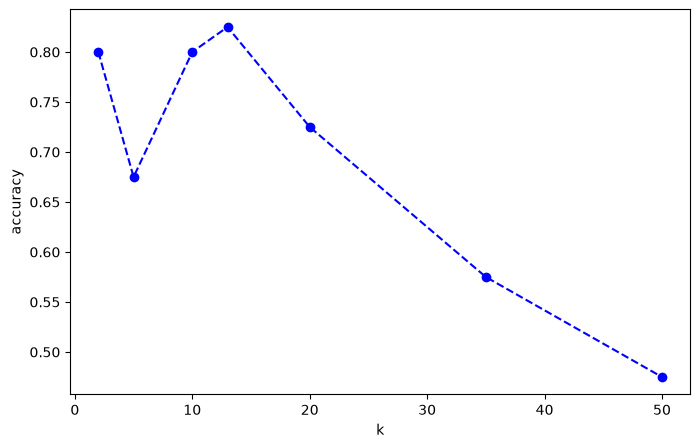

In [18]:

wyniki = []
cechy = [2,5,10,13,20,35,50]

for i in cechy:
    X_3, y_3 = make_classification(
        n_samples=200, 
        n_features=i, 
        n_informative=2, 
        n_classes=2, 
        n_redundant=0,
        random_state=42)

    X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_3_train_scaled = scaler.fit_transform(X_3_train)
    X_3_test_scaled = scaler.transform(X_3_test)
    knn_scaled = KNeighborsClassifier(n_neighbors=5)
    knn_scaled.fit(X_3_train_scaled, y_3_train)
    wyniki.append(knn_scaled.score(X_3_test_scaled, y_3_test))
        
plt.figure(figsize=(8, 5))
plt.plot(cechy, wyniki, color='blue', marker='o', linestyle='--') 
plt.xlabel("k")
plt.ylabel("accuracy")
wyniki

k =13 ma najwieksza accuracy 